In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\craft\Desktop\PortfolioProject\smartphone_battery_features.csv")

In [40]:
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95


In [5]:
#look at the data
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95


In [6]:
#Check the missing data
for col in df.columns:
    per_missing = np.mean(df[col].isnull())
    print('{}-{}%'.format(col,per_missing))

Device_ID-0.0%
device_age_months-0.0%
battery_capacity_mah-0.0%
avg_screen_on_hours_per_day-0.0%
avg_charging_cycles_per_week-0.0%
avg_battery_temp_celsius-0.0%
fast_charging_usage_percent-0.0%
overnight_charging_freq_per_week-0.0%
gaming_hours_per_week-0.0%
video_streaming_hours_per_week-0.0%
background_app_usage_level-0.0%
signal_strength_avg-0.0%
charging_habit_score-0.0%
usage_intensity_score-0.0%
thermal_stress_index-0.0%


In [7]:
#Check the columns data types
df.dtypes

Device_ID                            object
device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level           object
signal_strength_avg                  object
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
dtype: object

In [12]:
#gaming_hours_per_week high correlation
df = df.sort_values(by=['gaming_hours_per_week'],ascending=False)
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
2203,ec6da945-8346-4389-b547-6d3675d24c99,30,3000,6.1,8.8,36.2,57.7,4,24.8,9.4,Medium,Good,7,10.0,5.63
91,23859060-f15a-4fe9-ac1f-40f65a06331c,40,3000,5.8,7.8,37.2,25.8,5,21.9,4.7,Low,Poor,6,10.0,5.65
902,c39dc00a-68e8-4c24-aa8a-bc70600cccb3,26,5000,7.6,11.4,33.7,32.5,5,20.0,10.1,High,Moderate,6,10.0,4.70
735,7fb6db6c-91dd-4f1c-a469-de5118e0cdc4,35,3000,7.7,12.0,32.7,13.9,5,18.2,18.9,Medium,Good,6,10.0,4.33
4903,b13c6c36-131a-46d0-a2b4-f4dffe090828,12,3000,6.9,12.0,40.7,65.1,0,18.2,1.6,Medium,Poor,7,10.0,6.18


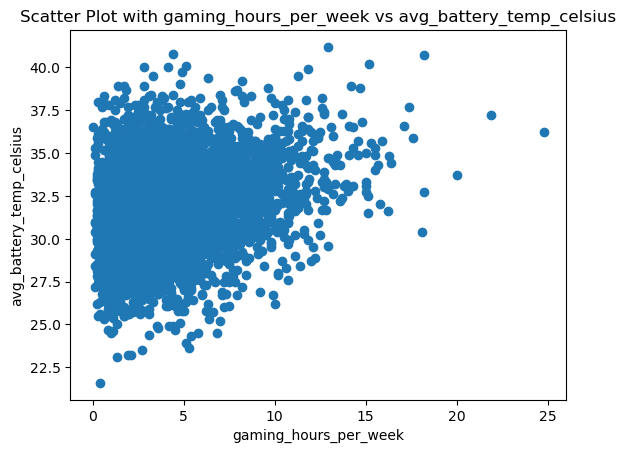

In [18]:
#Scatter Plot with gaming_hours_per_week vs avg_battery_temp_celsius
plt.scatter(x = df['gaming_hours_per_week'],y=df['avg_battery_temp_celsius'])
plt.title('Scatter Plot with gaming_hours_per_week vs avg_battery_temp_celsius')
plt.xlabel('gaming_hours_per_week')
plt.ylabel('avg_battery_temp_celsius')
plt.show()

<Axes: xlabel='gaming_hours_per_week', ylabel='avg_battery_temp_celsius'>

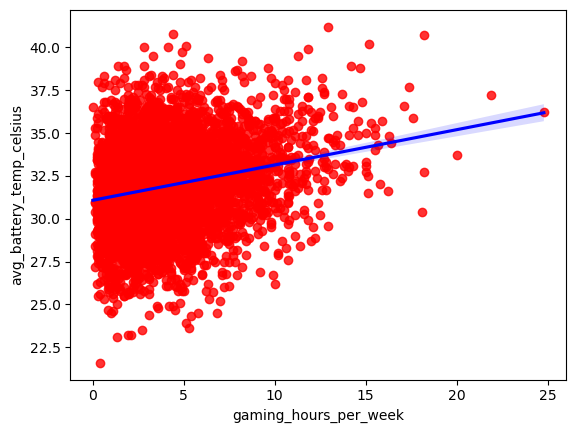

In [24]:
sns.regplot(x='gaming_hours_per_week',y='avg_battery_temp_celsius',data = df,scatter_kws={'color':'red'},line_kws={'color':'blue'})

In [28]:
#Looking at Correlation
num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr(method='pearson')
corr

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,charging_habit_score,usage_intensity_score,thermal_stress_index
device_age_months,1.000000,0.009134,0.007993,0.003280,0.000991,-0.001268,-0.004451,0.009928,-0.023822,0.003761,-0.017038,0.004083
battery_capacity_mah,0.009134,1.000000,0.005573,-0.000833,-0.004179,0.005913,0.002408,-0.009302,-0.002772,-0.013143,-0.023360,-0.006665
avg_screen_on_hours_per_day,0.007993,0.005573,1.000000,0.944622,0.396316,0.019395,-0.021555,0.012077,0.000268,-0.103779,0.062645,0.352464
avg_charging_cycles_per_week,0.003280,-0.000833,0.944622,1.000000,0.369304,0.017885,-0.025370,0.005216,0.007862,-0.108673,0.047997,0.326642
avg_battery_temp_celsius,0.000991,-0.004179,0.396316,0.369304,1.000000,0.015058,-0.014870,0.229172,-0.000455,-0.038782,0.031323,0.951569
fast_charging_usage_percent,-0.001268,0.005913,0.019395,0.017885,0.015058,1.000000,-0.014530,0.022819,0.009404,-0.353090,0.022603,0.020096
overnight_charging_freq_per_week,-0.004451,0.002408,-0.021555,-0.025370,-0.014870,-0.014530,1.000000,0.012411,0.010663,-0.797665,-0.024009,-0.009111
gaming_hours_per_week,0.009928,-0.009302,0.012077,0.005216,0.229172,0.022819,0.012411,1.000000,-0.020754,-0.020455,0.027642,0.516848
video_streaming_hours_per_week,-0.023822,-0.002772,0.000268,0.007862,-0.000455,0.009404,0.010663,-0.020754,1.000000,-0.015816,0.038336,-0.007539
charging_habit_score,0.003761,-0.013143,-0.103779,-0.108673,-0.038782,-0.353090,-0.797665,-0.020455,-0.015816,1.000000,0.000261,-0.040463


In [ ]:
#Although a positive trend is observed, the wide dispersion suggests that gaming is not the only factor affecting battery temperature.

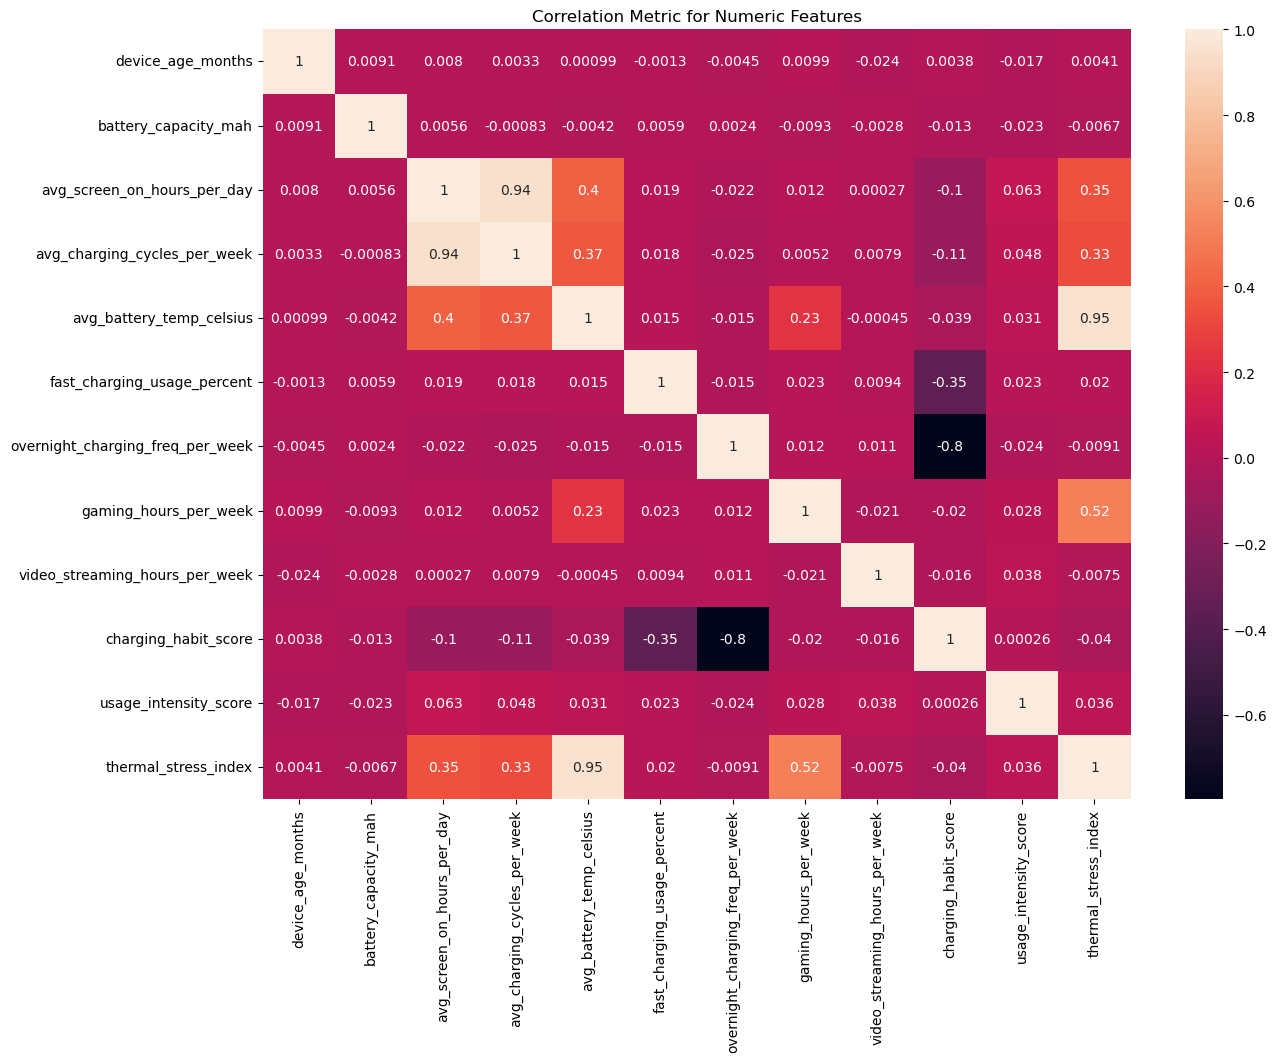

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True)
plt.title('Correlation Metric for Numeric Features')
plt.show()

In [33]:
corr_pairs = corr.unstack()
corr_pairs


device_age_months     device_age_months                 1.000000
                      battery_capacity_mah              0.009134
                      avg_screen_on_hours_per_day       0.007993
                      avg_charging_cycles_per_week      0.003280
                      avg_battery_temp_celsius          0.000991
                                                          ...   
thermal_stress_index  gaming_hours_per_week             0.516848
                      video_streaming_hours_per_week   -0.007539
                      charging_habit_score             -0.040463
                      usage_intensity_score             0.036282
                      thermal_stress_index              1.000000
Length: 144, dtype: float64

In [35]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

charging_habit_score              overnight_charging_freq_per_week   -0.797665
overnight_charging_freq_per_week  charging_habit_score               -0.797665
charging_habit_score              fast_charging_usage_percent        -0.353090
fast_charging_usage_percent       charging_habit_score               -0.353090
charging_habit_score              avg_charging_cycles_per_week       -0.108673
                                                                        ...   
avg_charging_cycles_per_week      avg_charging_cycles_per_week        1.000000
avg_screen_on_hours_per_day       avg_screen_on_hours_per_day         1.000000
battery_capacity_mah              battery_capacity_mah                1.000000
usage_intensity_score             usage_intensity_score               1.000000
thermal_stress_index              thermal_stress_index                1.000000
Length: 144, dtype: float64

In [39]:
high_corr = sorted_pairs[(sorted_pairs) > 0.3]
high_corr

thermal_stress_index              avg_charging_cycles_per_week        0.326642
avg_charging_cycles_per_week      thermal_stress_index                0.326642
thermal_stress_index              avg_screen_on_hours_per_day         0.352464
avg_screen_on_hours_per_day       thermal_stress_index                0.352464
avg_charging_cycles_per_week      avg_battery_temp_celsius            0.369304
avg_battery_temp_celsius          avg_charging_cycles_per_week        0.369304
                                  avg_screen_on_hours_per_day         0.396316
avg_screen_on_hours_per_day       avg_battery_temp_celsius            0.396316
thermal_stress_index              gaming_hours_per_week               0.516848
gaming_hours_per_week             thermal_stress_index                0.516848
avg_screen_on_hours_per_day       avg_charging_cycles_per_week        0.944622
avg_charging_cycles_per_week      avg_screen_on_hours_per_day         0.944622
thermal_stress_index              avg_battery_temp_c

In [ ]:
#Gaming has a stronger impact on battery temperature than charging behavior.
#That's exactly what I suspected.